### K Means Clustering from Scratch 

In [2]:
#loading mall customers dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder

#loading the dataset
mall_data = pd.read_csv('Mall_Customers.csv')
print(f"dataset shape: {mall_data.shape}")
mall_data.head()
mall_data.info()
mall_data.describe()
mall_data.isnull().sum()

#visualization of the data
sns.set_style('whitegrid')
%matplotlib inline

dataset shape: (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


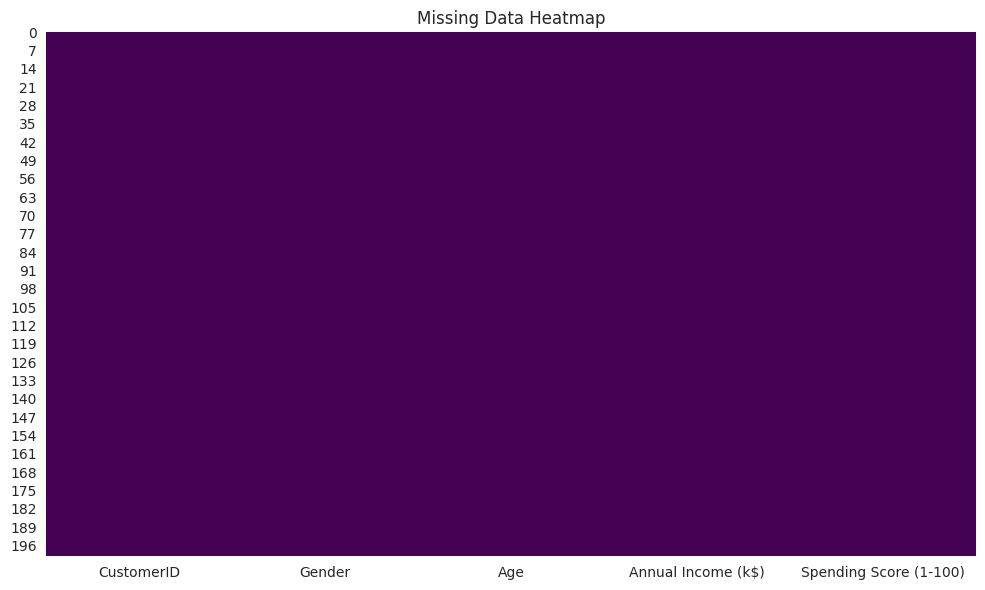

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [3]:
#Visualize missing data 
plt.figure(figsize=(10,6))
sns.heatmap(mall_data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

#Missing value count 
print(mall_data.isnull().sum())


In [4]:
mall_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
mall_data.drop('CustomerID', axis=1, inplace=True)

In [6]:
mall_data

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


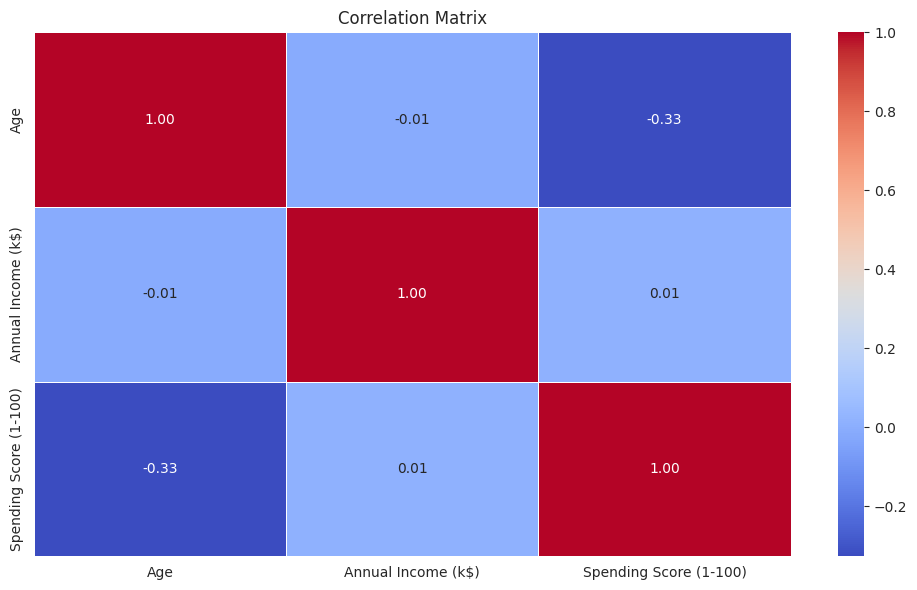

In [7]:
#Correlation Matrix 
plt.figure(figsize=(10,6))
corr = mall_data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt="0.2f",linewidths=0.5)    
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
mall_data.dtypes

Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [9]:
#OneHotEncoding of Gender 
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(mall_data[['Gender']])

# 3. Convert back to a DataFrame for readability
encoded_df = pd.DataFrame(
    encoded_data, 
    columns=encoder.get_feature_names_out(['Gender'])
)
print(encoded_df)

     Gender_Female  Gender_Male
0              0.0          1.0
1              0.0          1.0
2              1.0          0.0
3              1.0          0.0
4              1.0          0.0
..             ...          ...
195            1.0          0.0
196            1.0          0.0
197            0.0          1.0
198            0.0          1.0
199            0.0          1.0

[200 rows x 2 columns]


In [10]:
# Initialize k centroids randomly
feature_cols = ['Annual Income (k$)', 'Spending Score (1-100)']
X = mall_data[feature_cols].to_numpy(dtype=float)

k = 5
#Random initialization of centroids
rng = np.random.default_rng(42)
initial_idx = rng.choice(X.shape[0], size=k, replace=False)
centroids = X[initial_idx].copy()

print('Initial centroid indices:', initial_idx)
print('Initial centroids:\n', centroids)

Initial centroid indices: [152  87 129  17  86]
Initial centroids:
 [[78. 20.]
 [57. 55.]
 [71. 75.]
 [21. 66.]
 [57. 58.]]


In [11]:
# Assign points to nearest centroid
distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
labels = np.argmin(distances, axis=1)

print('Cluster counts after initial assignment:')
print(pd.Series(labels).value_counts().sort_index())

Cluster counts after initial assignment:
0    44
1    70
2    39
3    34
4    13
Name: count, dtype: int64


In [12]:
# Update centroids by calculating mean of points in each cluster
new_centroids = centroids.copy()
for j in range(k):
    cluster_points = X[labels == j]
    if len(cluster_points) > 0:
        new_centroids[j] = cluster_points.mean(axis=0)
    else:
        # Handle empty cluster
        new_centroids[j] = X[rng.integers(0, X.shape[0])]

centroids = new_centroids
print('Centroids after one update step:\n', centroids)

Centroids after one update step:
 [[79.09090909 17.15909091]
 [53.45714286 46.78571429]
 [86.53846154 82.12820513]
 [24.         60.02941176]
 [53.76923077 58.92307692]]


In [13]:
# Repeat assignment + update for 10 iterations
n_iters = 10
centroid_history = [centroids.copy()]

for i in range(n_iters):
    distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = np.argmin(distances, axis=1)

    updated = centroids.copy()
    for j in range(k):
        cluster_points = X[labels == j]
        if len(cluster_points) > 0:
            updated[j] = cluster_points.mean(axis=0)
        else:
            updated[j] = X[rng.integers(0, X.shape[0])]

    centroids = updated
    centroid_history.append(centroids.copy())

manual_inertia = np.sum((X - centroids[labels]) ** 2)
print(f'Final manual centroids after {n_iters} iterations:\n{centroids}')
print(f'Manual inertia: {manual_inertia:.2f}')

Final manual centroids after 10 iterations:
[[87.75       17.58333333]
 [26.30434783 20.91304348]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [55.0875     49.7125    ]]
Manual inertia: 44454.48


In [14]:
# Compare with sklearn.KMeans
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
kmeans.fit(X)

print('Sklearn centroids:\n', kmeans.cluster_centers_)
print(f'Sklearn inertia: {kmeans.inertia_:.2f}')

comparison_df = pd.DataFrame({
    'Metric': ['Manual inertia', 'Sklearn inertia'],
    'Value': [manual_inertia, kmeans.inertia_]
})
comparison_df

Sklearn centroids:
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]
Sklearn inertia: 44448.46


,Metric,Value
0,Manual inertia,44454.476480
1,Sklearn inertia,44448.455448


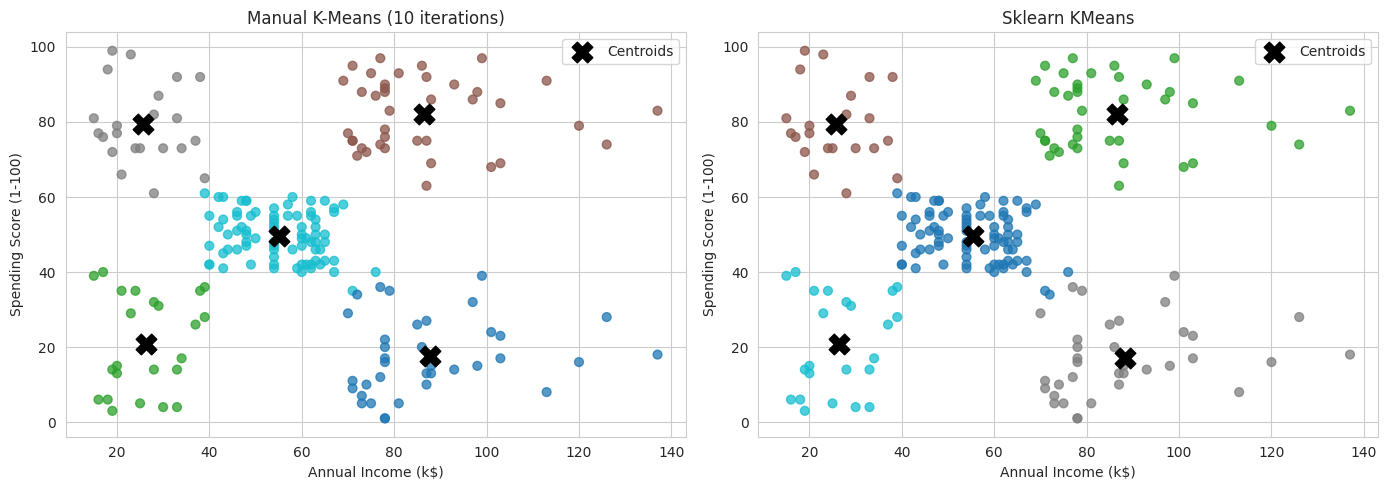

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#KMeasns subplot
axes[0].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=40, alpha=0.75)
axes[0].scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=220, label='Centroids')
axes[0].set_title('Manual K-Means (10 iterations)')
axes[0].set_xlabel(feature_cols[0])
axes[0].set_ylabel(feature_cols[1])
axes[0].legend()

#Sklearn KMeans subplot
axes[1].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='tab10', s=40, alpha=0.75)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='X', s=220, label='Centroids')
axes[1].set_title('Sklearn KMeans')
axes[1].set_xlabel(feature_cols[0])
axes[1].set_ylabel(feature_cols[1])
axes[1].legend()

plt.tight_layout()
plt.show()

In [16]:
# Quick centroid comparison table
manual_centroids_df = pd.DataFrame(centroids, columns=feature_cols)
manual_centroids_df['source'] = 'manual'

sk_centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
sk_centroids_df['source'] = 'sklearn'

pd.concat([manual_centroids_df, sk_centroids_df], ignore_index=True)

,Annual Income (k$),Spending Score (1-100),source
0,87.750000,17.583333,manual
1,26.304348,20.913043,manual
2,86.538462,82.128205,manual
3,25.727273,79.363636,manual
4,55.087500,49.712500,manual
5,55.296296,49.518519,sklearn
6,86.538462,82.128205,sklearn
7,25.727273,79.363636,sklearn
8,88.200000,17.114286,sklearn
9,26.304348,20.913043,sklearn
